In [1]:
from google.colab import files
uploaded = files.upload()

Saving aa_dataset-tickets-multi-lang-5-2-50-version.csv to aa_dataset-tickets-multi-lang-5-2-50-version.csv


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, mean_absolute_error
from transformers import DistilBertModel, AutoTokenizer, get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

raw = pd.read_csv("aa_dataset-tickets-multi-lang-5-2-50-version.csv")
raw = raw[raw["language"] == "en"].copy()
raw["text"] = (raw["subject"].fillna("") + ". " + raw["body"].fillna("")).str.strip()
raw = raw.dropna(subset=["text", "queue", "priority"])
raw = raw[raw["text"].str.len() > 10]
raw["text_len_words"] = raw["text"].str.split().str.len()

priority_base_minutes = {"low": 15, "medium": 25, "high": 40, "critical": 60}
raw["priority_norm"] = raw["priority"].str.lower().str.strip()
raw["base_handle_time"] = raw["priority_norm"].map(priority_base_minutes).fillna(25)
np.random.seed(42)
length_factor = (raw["text_len_words"] / raw["text_len_words"].median()).clip(0.5, 3.0)
noise = np.random.normal(1.0, 0.15, size=len(raw)).clip(0.6, 1.6)
raw["estimated_handle_time_min"] = (raw["base_handle_time"] * length_factor * noise).round(1)

df = raw[["text", "queue", "priority_norm", "estimated_handle_time_min"]].rename(columns={"priority_norm": "priority"})
print("CLEANED SHAPE:", df.shape)

queue_encoder = LabelEncoder()
priority_encoder = LabelEncoder()
df["queue_label"] = queue_encoder.fit_transform(df["queue"])
df["priority_label"] = priority_encoder.fit_transform(df["priority"])
n_queue = len(queue_encoder.classes_)
n_priority = len(priority_encoder.classes_)
print("QUEUE CLASSES:", list(queue_encoder.classes_))
print("PRIORITY CLASSES:", list(priority_encoder.classes_))

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["queue_label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["queue_label"], random_state=42)
print("SPLIT SIZES:", len(train_df), len(val_df), len(test_df))

time_mean = train_df["estimated_handle_time_min"].mean()
time_std = train_df["estimated_handle_time_min"].std()
train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
train_df["time_norm"] = (train_df["estimated_handle_time_min"] - time_mean) / time_std
val_df["time_norm"] = (val_df["estimated_handle_time_min"] - time_mean) / time_std
test_df["time_norm"] = (test_df["estimated_handle_time_min"] - time_mean) / time_std
print("TIME MEAN/STD:", time_mean, time_std)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

class MultiTaskDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df["text"].tolist()
        self.queue_labels = df["queue_label"].tolist()
        self.priority_labels = df["priority_label"].tolist()
        self.time_labels = df["time_norm"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding="max_length",
                              max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "queue_labels": torch.tensor(self.queue_labels[idx], dtype=torch.long),
            "priority_labels": torch.tensor(self.priority_labels[idx], dtype=torch.long),
            "time_labels": torch.tensor(self.time_labels[idx], dtype=torch.float),
        }

train_loader = DataLoader(MultiTaskDataset(train_df, tokenizer), batch_size=16, shuffle=True)
val_loader = DataLoader(MultiTaskDataset(val_df, tokenizer), batch_size=32)
test_loader = DataLoader(MultiTaskDataset(test_df, tokenizer), batch_size=32)

class MultiTaskDistilBERT(nn.Module):
    def __init__(self, n_queue, n_priority):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.1)
        self.queue_head = nn.Linear(768, n_queue)
        self.priority_head = nn.Linear(768, n_priority)
        self.time_head = nn.Linear(768, 1)
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0])
        return self.queue_head(cls), self.priority_head(cls), self.time_head(cls)

model = MultiTaskDistilBERT(n_queue, n_priority).to(device)
queue_loss_fn = nn.CrossEntropyLoss()
priority_loss_fn = nn.CrossEntropyLoss()
time_loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

NUM_EPOCHS = 8
print(">>> THIS RUN WILL EXECUTE", NUM_EPOCHS, "EPOCHS <<<")
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        queue_labels = batch["queue_labels"].to(device)
        priority_labels = batch["priority_labels"].to(device)
        time_labels = batch["time_labels"].to(device)
        if train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            queue_logits, priority_logits, handle_time = model(input_ids, attention_mask)
            l1 = queue_loss_fn(queue_logits, queue_labels)
            l2 = priority_loss_fn(priority_logits, priority_labels)
            l3 = time_loss_fn(handle_time.squeeze(-1), time_labels)
            loss = l1 + l2 + 0.5 * l3
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

for epoch in range(NUM_EPOCHS):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS} | train_loss={tr:.4f} | val_loss={va:.4f}")

model.eval()
qp, qt, pp, pt_, tp, qc, pc = [], [], [], [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        ql, pl, ht = model(input_ids, attention_mask)
        qprob = torch.softmax(ql, dim=1)
        pprob = torch.softmax(pl, dim=1)
        qp.extend(qprob.argmax(1).cpu().numpy()); qc.extend(qprob.max(1).values.cpu().numpy())
        pp.extend(pprob.argmax(1).cpu().numpy()); pc.extend(pprob.max(1).values.cpu().numpy())
        tp.extend((ht.squeeze(-1).cpu().numpy() * time_std) + time_mean)
        qt.extend(batch["queue_labels"].numpy()); pt_.extend(batch["priority_labels"].numpy())

print("\n=== QUEUE REPORT ===")
print(classification_report(qt, qp, target_names=queue_encoder.classes_, zero_division=0))
print("\n=== PRIORITY REPORT ===")
print(classification_report(pt_, pp, target_names=priority_encoder.classes_, zero_division=0))
mae = mean_absolute_error(test_df["estimated_handle_time_min"].values, tp)
print(f"\nHANDLE TIME MAE: {mae:.2f} minutes")

test_df = test_df.reset_index(drop=True)
test_df["pred_queue"] = queue_encoder.inverse_transform(qp)
test_df["pred_queue_confidence"] = qc
test_df["pred_priority"] = priority_encoder.inverse_transform(pp)
test_df["pred_priority_confidence"] = pc
test_df["pred_handle_time_min"] = tp
test_df.to_csv("test_predictions_v2.csv", index=False)
torch.save(model.state_dict(), "multitask_distilbert.pt")
print("\nSAVED.")

DEVICE: cuda
CLEANED SHAPE: (16338, 4)
QUEUE CLASSES: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']
PRIORITY CLASSES: ['high', 'low', 'medium']
SPLIT SIZES: 11436 2451 2451
TIME MEAN/STD: 29.256636935991608 16.365854175143948


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


>>> THIS RUN WILL EXECUTE 8 EPOCHS <<<
EPOCH 1/8 | train_loss=3.2409 | val_loss=2.9843
EPOCH 2/8 | train_loss=2.8162 | val_loss=2.7103
EPOCH 3/8 | train_loss=2.4812 | val_loss=2.5941
EPOCH 4/8 | train_loss=2.1069 | val_loss=2.4987
EPOCH 5/8 | train_loss=1.7676 | val_loss=2.4690
EPOCH 6/8 | train_loss=1.4971 | val_loss=2.4493
EPOCH 7/8 | train_loss=1.3064 | val_loss=2.4561
EPOCH 8/8 | train_loss=1.1882 | val_loss=2.4532

=== QUEUE REPORT ===
                                 precision    recall  f1-score   support

           Billing and Payments       0.85      0.79      0.82       239
               Customer Service       0.44      0.49      0.46       361
                General Inquiry       0.67      0.06      0.10        36
                Human Resources       0.80      0.23      0.36        52
                     IT Support       0.48      0.40      0.44       292
                Product Support       0.50      0.51      0.50       461
          Returns and Exchanges       0.58 

In [10]:
demand_per_queue = sim_df.groupby("pred_queue")["pred_handle_time_min"].sum().sort_values(ascending=False)
print("Total demand (minutes) per queue:\n", demand_per_queue)

for q in demand_per_queue.index:
    covering_agents = [a for a in agents if q in a["skills"]]
    total_cap = sum(a["capacity_min"] for a in covering_agents)
    status = "OK" if total_cap >= demand_per_queue[q] else "SHORT by " + str(round(demand_per_queue[q] - total_cap, 1))
    print(f"{q}: demand={demand_per_queue[q]:.1f} | capacity={total_cap} | agents={[a['agent_id'] for a in covering_agents]} | {status}")

Total demand (minutes) per queue:
 pred_queue
Technical Support                  1207.524765
Customer Service                    506.997035
Billing and Payments                460.672709
IT Support                          340.910797
Product Support                     278.150200
Returns and Exchanges                53.393231
Service Outages and Maintenance      46.843230
Name: pred_handle_time_min, dtype: float64
Technical Support: demand=1207.5 | capacity=1200 | agents=['A1', 'A2', 'A3', 'A3b', 'A3c'] | SHORT by 7.5
Customer Service: demand=507.0 | capacity=720 | agents=['A4', 'A5', 'A10'] | OK
Billing and Payments: demand=460.7 | capacity=480 | agents=['A6', 'A6b'] | OK
IT Support: demand=340.9 | capacity=480 | agents=['A1', 'A7'] | OK
Product Support: demand=278.2 | capacity=480 | agents=['A2', 'A8'] | OK
Returns and Exchanges: demand=53.4 | capacity=480 | agents=['A5', 'A8'] | OK
Service Outages and Maintenance: demand=46.8 | capacity=240 | agents=['A7'] | OK


Loaded predictions: (2451, 12)
--- BASELINE: FIFO ---
Avg wait: 99.2 min | SLA breaches: 64/100
Total weighted completion time: 28315.7

Phase 1 (assignment) status: Optimal

--- OPTIMIZED (Assignment IP + Smith's Rule) ---
Avg wait: 68.7 min | SLA breaches: 48/100
Total weighted completion time: 21285.2


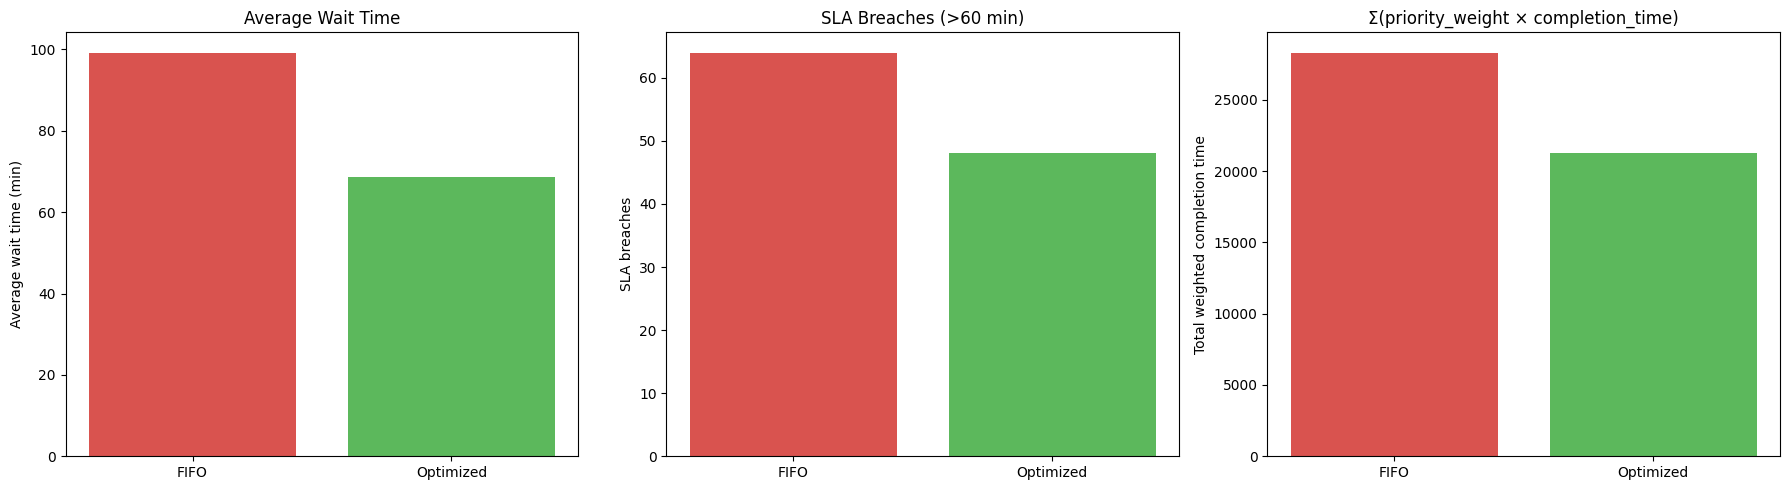


Wait time reduction: 30.7%
SLA breach reduction: 25.0%
Total weighted completion time reduction: 24.8%

Saved routing_results_v3.csv


In [13]:
# ============================================================
# STAGE 3 (v3): Parallel-Machine Scheduling with Weighted
#               Completion Time Minimization
#
# Phase 1: Assignment IP — decide which agent handles each ticket
#          (skill-eligibility + capacity constraints, load-balanced).
# Phase 2: Smith's Rule sequencing — within each agent's assigned
#          tickets, sequence by decreasing w/p ratio. This is
#          PROVABLY OPTIMAL for minimizing total weighted completion
#          time on a single machine, given a fixed job set.
#
# This assignment-IP + Smith's-Rule decomposition is the standard
# approach for parallel-machine weighted completion time problems
# (the joint problem, R||sum(w_j C_j), is NP-hard in general).
# ============================================================

import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

df = pd.read_csv("test_predictions_v2.csv")
print("Loaded predictions:", df.shape)

np.random.seed(42)
sim_df = df.sample(n=100, random_state=42).reset_index(drop=True)
sim_df["ticket_id"] = sim_df.index

priority_weight = {"high": 3, "medium": 2, "low": 1}
sim_df["priority_weight"] = sim_df["pred_priority"].map(priority_weight)
sim_df["p"] = sim_df["pred_handle_time_min"]
sim_df["w"] = sim_df["priority_weight"]

agents = [
    {"agent_id": "A1", "skills": ["Technical Support", "IT Support"], "capacity_min": 240},
    {"agent_id": "A2", "skills": ["Technical Support", "Product Support"], "capacity_min": 240},
    {"agent_id": "A3", "skills": ["Technical Support"], "capacity_min": 240},
    {"agent_id": "A3b", "skills": ["Technical Support"], "capacity_min": 240},
    {"agent_id": "A3c", "skills": ["Technical Support"], "capacity_min": 240},
    {"agent_id": "A3d", "skills": ["Technical Support"], "capacity_min": 240},
    {"agent_id": "A3e", "skills": ["Technical Support"], "capacity_min": 240},
    {"agent_id": "A4", "skills": ["Customer Service", "General Inquiry"], "capacity_min": 240},
    {"agent_id": "A5", "skills": ["Customer Service", "Returns and Exchanges"], "capacity_min": 240},
    {"agent_id": "A6", "skills": ["Billing and Payments", "Sales and Pre-Sales"], "capacity_min": 240},
    {"agent_id": "A6b", "skills": ["Billing and Payments"], "capacity_min": 240},
    {"agent_id": "A7", "skills": ["IT Support", "Service Outages and Maintenance"], "capacity_min": 240},
    {"agent_id": "A8", "skills": ["Product Support", "Returns and Exchanges"], "capacity_min": 240},
    {"agent_id": "A9", "skills": ["Human Resources", "General Inquiry"], "capacity_min": 240},
    {"agent_id": "A10", "skills": ["Sales and Pre-Sales", "Customer Service"], "capacity_min": 240},
]
agent_df = pd.DataFrame(agents)
agent_ids = agent_df["agent_id"].tolist()
agent_skill_map = dict(zip(agent_df["agent_id"], agent_df["skills"]))
agent_capacity_map = dict(zip(agent_df["agent_id"], agent_df["capacity_min"]))

# ------------------------------------------------------------
# BASELINE: FIFO
# ------------------------------------------------------------
def fifo_weighted_completion(tickets_df, agents_list):
    agent_remaining = {a["agent_id"]: a["capacity_min"] for a in agents_list}
    cum_time = {a["agent_id"]: 0 for a in agents_list}
    total_wc = 0
    waits = []
    breaches = 0
    sla_limit = 60
    for _, row in tickets_df.iterrows():
        needed_skill = row["pred_queue"]
        p = row["p"]
        w = row["w"]
        assigned = None
        for a in agents_list:
            if needed_skill in a["skills"] and agent_remaining[a["agent_id"]] >= p:
                assigned = a["agent_id"]
                break
        if assigned is None:
            waits.append(120)
            breaches += 1
            continue
        wait = cum_time[assigned]
        cum_time[assigned] += p
        completion = cum_time[assigned]
        total_wc += w * completion
        agent_remaining[assigned] -= p
        waits.append(wait)
        if wait > sla_limit:
            breaches += 1
    return total_wc, waits, breaches

fifo_twc, fifo_waits, fifo_breaches = fifo_weighted_completion(sim_df, agents)
print(f"--- BASELINE: FIFO ---")
print(f"Avg wait: {np.mean(fifo_waits):.1f} min | SLA breaches: {fifo_breaches}/{len(sim_df)}")
print(f"Total weighted completion time: {fifo_twc:.1f}")

# ------------------------------------------------------------
# PHASE 1: Assignment IP (load-balanced, skill-eligible, capacity-feasible)
# ------------------------------------------------------------
prob = pulp.LpProblem("Phase1_Assignment", pulp.LpMinimize)
tickets = sim_df["ticket_id"].tolist()
x = pulp.LpVariable.dicts("assign", [(i, j) for i in tickets for j in agent_ids], cat="Binary")
max_load = pulp.LpVariable("max_load", lowBound=0)

prob += max_load

for i in tickets:
    prob += pulp.lpSum(x[(i, j)] for j in agent_ids) == 1

for i in tickets:
    needed_skill = sim_df.loc[sim_df["ticket_id"] == i, "pred_queue"].values[0]
    for j in agent_ids:
        if needed_skill not in agent_skill_map[j]:
            prob += x[(i, j)] == 0

for j in agent_ids:
    load_expr = pulp.lpSum(
        sim_df.loc[sim_df["ticket_id"] == i, "p"].values[0] * x[(i, j)] for i in tickets
    )
    prob += load_expr <= agent_capacity_map[j]
    prob += load_expr <= max_load

prob.solve(pulp.PULP_CBC_CMD(msg=0))
print(f"\nPhase 1 (assignment) status: {pulp.LpStatus[prob.status]}")
if pulp.LpStatus[prob.status] != "Optimal":
    raise RuntimeError(f"Phase 1 infeasible: {pulp.LpStatus[prob.status]}")

assignment = {}
for i in tickets:
    for j in agent_ids:
        if pulp.value(x[(i, j)]) == 1:
            assignment[i] = j
sim_df["assigned_agent"] = sim_df["ticket_id"].map(assignment)

# ------------------------------------------------------------
# PHASE 2: Smith's Rule sequencing (WSPT: decreasing w/p ratio)
# ------------------------------------------------------------
sim_df["wp_ratio"] = sim_df["w"] / sim_df["p"]

results = []
for agent in agent_ids:
    agent_tickets = sim_df[sim_df["assigned_agent"] == agent].copy()
    if len(agent_tickets) == 0:
        continue
    agent_tickets = agent_tickets.sort_values("wp_ratio", ascending=False)
    cum_time = 0
    for _, row in agent_tickets.iterrows():
        wait = cum_time
        cum_time += row["p"]
        completion = cum_time
        results.append({
            "ticket_id": row["ticket_id"],
            "wait_min": wait,
            "completion_min": completion,
        })

result_df = pd.DataFrame(results)
sim_df = sim_df.merge(result_df, on="ticket_id")

sla_limit = 60
opt_waits = sim_df["wait_min"].tolist()
opt_breaches = int((sim_df["wait_min"] > sla_limit).sum())
total_weighted_completion = (sim_df["w"] * sim_df["completion_min"]).sum()

print(f"\n--- OPTIMIZED (Assignment IP + Smith's Rule) ---")
print(f"Avg wait: {np.mean(opt_waits):.1f} min | SLA breaches: {opt_breaches}/{len(sim_df)}")
print(f"Total weighted completion time: {total_weighted_completion:.1f}")

# ------------------------------------------------------------
# Comparison
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(["FIFO", "Optimized"], [np.mean(fifo_waits), np.mean(opt_waits)], color=["#d9534f", "#5cb85c"])
axes[0].set_ylabel("Average wait time (min)")
axes[0].set_title("Average Wait Time")

axes[1].bar(["FIFO", "Optimized"], [fifo_breaches, opt_breaches], color=["#d9534f", "#5cb85c"])
axes[1].set_ylabel("SLA breaches")
axes[1].set_title(f"SLA Breaches (>{sla_limit} min)")

axes[2].bar(["FIFO", "Optimized"], [fifo_twc, total_weighted_completion], color=["#d9534f", "#5cb85c"])
axes[2].set_ylabel("Total weighted completion time")
axes[2].set_title("Σ(priority_weight × completion_time)")

plt.tight_layout()
plt.savefig("or_comparison_v3.png", dpi=150)
plt.show()

wait_improve = (1 - np.mean(opt_waits) / np.mean(fifo_waits)) * 100
breach_improve = (1 - opt_breaches / max(fifo_breaches, 1)) * 100
twc_improve = (1 - total_weighted_completion / fifo_twc) * 100

print(f"\nWait time reduction: {wait_improve:.1f}%")
print(f"SLA breach reduction: {breach_improve:.1f}%")
print(f"Total weighted completion time reduction: {twc_improve:.1f}%")

sim_df.to_csv("routing_results_v3.csv", index=False)
print("\nSaved routing_results_v3.csv")